# Laboratorio 5 · Clasificación y sentimiento de tweets

**Curso:** CC3084 · Data Science  
**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data)  
**Entrada:** `data/processed/train_limpio_lema_2gramas.csv`

Este notebook continúa el trabajo de exploración y limpieza y resuelve los **ejercicios 6 al 10**:

1. comparar varios clasificadores de tweets;
2. explicar cómo se incorpora el contexto;
3. construir una función que clasifique un tweet nuevo;
4. medir sentimiento positivo, negativo y neutral;
5. identificar los diez tweets más positivos y negativos;
6. determinar si los tweets de desastres reales son más negativos;
7. incorporar la negatividad como variable adicional y medir su efecto.

## Diseño experimental

Se reserva desde el inicio un **20% estratificado** como prueba final. El 80% restante se usa para comparar modelos mediante validación cruzada estratificada de cinco particiones. Todo el aprendizaje de vocabulario y pesos TF–IDF ocurre dentro de cada partición mediante un `Pipeline`, evitando fuga de información.

La métrica principal es **F1 de la clase desastre**, porque las clases tienen un desbalance moderado y nos interesan simultáneamente precisión y exhaustividad. También se reportan *accuracy*, precisión, *recall* y ROC-AUC.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from scipy.stats import mannwhitneyu
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    make_scorer, precision_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

# Funciona al ejecutar desde la raíz del repositorio o desde notebook/.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_PATH = ROOT / "data" / "processed" / "train_limpio_lema_2gramas.csv"
df = pd.read_csv(DATA_PATH)

required = {"id", "text", "target", "texto_limpio"}
assert required.issubset(df.columns), f"Faltan columnas: {required - set(df.columns)}"
assert df["target"].isin([0, 1]).all(), "target debe contener únicamente 0 y 1"
assert df["texto_limpio"].fillna("").str.strip().ne("").all(), "Hay textos limpios vacíos"

print(f"Datos: {df.shape[0]:,} tweets, {df.shape[1]} columnas")
display(df[["id", "text", "texto_limpio", "target"]].head(3))

Datos: 7,613 tweets, 18 columnas


,id,text,texto_limpio,target
0,1,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason flaghashtag earthquake may allah forgive,1
1,4,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1
2,5,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,resident ask shelter place notify officer no evacuation shelter place order expect,1


## 6. Modelos de clasificación

### ¿Cómo se aborda el contexto?

El texto se representa con **TF–IDF de unigramas y bigramas** (`ngram_range=(1, 2)`). Los unigramas capturan palabras discriminantes como `wildfire`; los bigramas conservan contexto local en expresiones como `forest fire`, `suicide bomber` o `body bag`. Se usa `min_df=2` para excluir términos que aparecen una sola vez: el notebook anterior mostró que agregar bigramas produce una mejora pequeña, pero que filtrar términos únicos reduce mucho el ruido.

Esta representación no comprende relaciones de largo alcance, ironía ni conocimiento del mundo; solo aproxima el contexto mediante coocurrencias locales. Es una elección proporcional al tamaño del corpus y permite comparar modelos rápidos e interpretables.

Se comparan cuatro familias y una línea base:

- clase mayoritaria, para saber qué se logra sin aprender texto;
- regresión logística, lineal e interpretable;
- SVM lineal, apropiada para matrices dispersas de alta dimensión;
- Naive Bayes complementario, diseñado para conteos desbalanceados;
- descenso de gradiente estocástico con pérdida *modified Huber*.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texto_limpio"], df["target"],
    test_size=0.20, random_state=SEED, stratify=df["target"]
)

print(f"Entrenamiento/validación: {len(X_train):,} ({len(X_train)/len(df):.0%})")
print(f"Prueba final:             {len(X_test):,} ({len(X_test)/len(df):.0%})")
print("Proporción de desastre:",
      f"train={y_train.mean():.3f}, test={y_test.mean():.3f}")

Entrenamiento/validación: 6,090 (80%)
Prueba final:             1,523 (20%)
Proporción de desastre: train=0.430, test=0.429


In [3]:
def make_pipeline(model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, max_df=0.98,
            sublinear_tf=True, norm="l2"
        )),
        ("model", model),
    ])

models = {
    "Línea base (mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(C=2.0, max_iter=2_000, random_state=SEED),
    "SVM lineal": LinearSVC(C=1.0, random_state=SEED),
    "Naive Bayes complementario": ComplementNB(alpha=0.5),
    "SGD (modified Huber)": SGDClassifier(
        loss="modified_huber", alpha=1e-5, max_iter=2_000,
        early_stopping=True, validation_fraction=0.1, random_state=SEED
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "accuracy": "accuracy", "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"
}

rows = []
for name, estimator in models.items():
    scores = cross_validate(
        make_pipeline(estimator), X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=1
    )
    row = {"Modelo": name}
    for metric in scoring:
        row[metric] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std(ddof=1)
    rows.append(row)

cv_results = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
display(cv_results[["Modelo", "accuracy", "precision", "recall", "f1", "f1_std", "roc_auc"]]
        .style.format({c: "{:.3f}" for c in ["accuracy", "precision", "recall", "f1", "f1_std", "roc_auc"]})
        .highlight_max(subset=["f1"], color="#b7e4c7"))

,Modelo,accuracy,precision,recall,f1,f1_std,roc_auc
0,Naive Bayes complementario,0.800,0.804,0.708,0.752,0.009,0.853
1,Regresión logística,0.798,0.808,0.695,0.747,0.009,0.853
2,SVM lineal,0.776,0.760,0.702,0.729,0.012,0.839
3,SGD (modified Huber),0.735,0.693,0.694,0.692,0.029,0.796
4,Línea base (mayoritaria),0.570,0.000,0.000,0.000,0.000,0.500


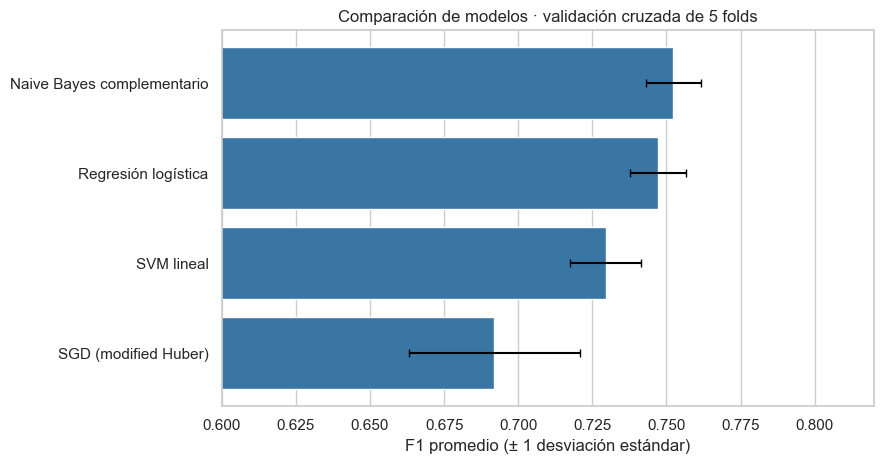

In [4]:
plot_cv = cv_results[cv_results["Modelo"] != "Línea base (mayoritaria)"].copy()
plt.figure(figsize=(9, 4.8))
ax = sns.barplot(data=plot_cv, x="f1", y="Modelo", color="#2878B5")
ax.errorbar(
    plot_cv["f1"], np.arange(len(plot_cv)), xerr=plot_cv["f1_std"],
    fmt="none", color="black", capsize=3
)
ax.set(xlim=(0.60, 0.82), xlabel="F1 promedio (± 1 desviación estándar)", ylabel="",
       title="Comparación de modelos · validación cruzada de 5 folds")
plt.tight_layout()
plt.show()

La selección se hace **exclusivamente con el F1 promedio de validación cruzada**. Solo después se ajusta el modelo ganador con todo el conjunto de entrenamiento y se abre una vez el conjunto de prueba. Esto mantiene la prueba como estimación no sesgada del rendimiento en tweets no vistos.

Modelo seleccionado: Naive Bayes complementario
ROC-AUC en prueba: 0.869

Reporte en el conjunto de prueba final:

              precision    recall  f1-score   support

 No desastre      0.816     0.892     0.852       869
    Desastre      0.836     0.732     0.781       654

    accuracy                          0.823      1523
   macro avg      0.826     0.812     0.816      1523
weighted avg      0.824     0.823     0.821      1523



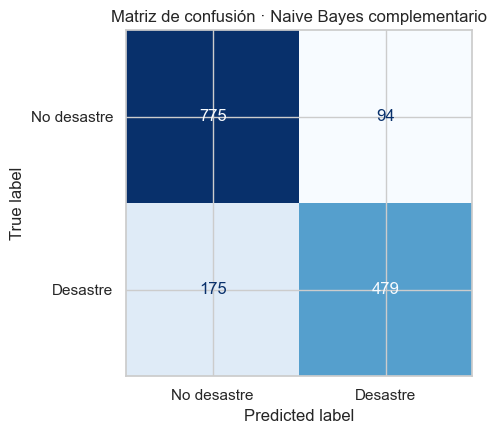

In [5]:
best_name = cv_results.loc[0, "Modelo"]
best_pipeline = make_pipeline(clone(models[best_name]))
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
if hasattr(best_pipeline.named_steps["model"], "predict_proba"):
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_score = best_pipeline.decision_function(X_test)

print("Modelo seleccionado:", best_name)
print("ROC-AUC en prueba:", f"{roc_auc_score(y_test, y_score):.3f}")
print("\nReporte en el conjunto de prueba final:\n")
print(classification_report(y_test, y_pred, target_names=["No desastre", "Desastre"], digits=3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No desastre", "Desastre"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión · {best_name}")
plt.tight_layout()
plt.show()

### Interpretación y errores

Los coeficientes de un modelo lineal —o la diferencia entre pesos de clase en Naive Bayes— permiten comprobar qué palabras o expresiones aprendió el clasificador. Los valores positivos se inclinan hacia **desastre real** y los negativos hacia **no desastre**. Después se muestran algunos falsos positivos y falsos negativos: suelen revelar usos figurados, titulares sin contexto, ironía o mensajes demasiado breves.

In [6]:
vectorizer = best_pipeline.named_steps["tfidf"]
fitted_model = best_pipeline.named_steps["model"]
feature_names = vectorizer.get_feature_names_out()

if hasattr(fitted_model, "coef_"):
    weights = np.asarray(fitted_model.coef_).ravel()
elif hasattr(fitted_model, "feature_log_prob_"):
    weights = fitted_model.feature_log_prob_[1] - fitted_model.feature_log_prob_[0]
else:
    weights = None

if weights is not None:
    important = pd.DataFrame({
        "Hacia no desastre": feature_names[np.argsort(weights)[:15]],
        "Peso no desastre": np.sort(weights)[:15],
        "Hacia desastre": feature_names[np.argsort(weights)[-15:][::-1]],
        "Peso desastre": np.sort(weights)[-15:][::-1],
    })
    display(important.style.format({"Peso no desastre": "{:.3f}", "Peso desastre": "{:.3f}"}))
else:
    print("El modelo seleccionado no expone pesos de términos comparables.")

errors = df.loc[X_test.index, ["id", "text", "target"]].copy()
errors["prediccion"] = y_pred
errors["score_desastre"] = y_score
print("Ejemplos de falsos positivos:")
display(errors[(errors.target == 0) & (errors.prediccion == 1)]
        .sort_values("score_desastre", ascending=False).head(5))
print("Ejemplos de falsos negativos:")
display(errors[(errors.target == 1) & (errors.prediccion == 0)]
        .sort_values("score_desastre").head(5))

,Hacia no desastre,Peso no desastre,Hacia desastre,Peso desastre
0,lmao,-2.450,mh370,3.309
1,blizzard,-2.298,hiroshima,3.250
2,write,-2.295,northern,3.135
3,cross body,-2.292,bomber,3.080
4,stretcher,-2.229,suicide bomber,3.068
5,harm,-2.226,debris,3.026
6,cake,-2.224,spill,2.995
7,career,-2.217,kill flagnumero,2.981
8,flaghashtag job,-2.210,severe,2.975
9,bag,-2.190,migrant,2.972


Ejemplos de falsos positivos:


,id,text,target,prediccion,score_desastre
2832,4076,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,0,1,0.986933
5267,7529,@TroySlaby22 slicker than an oil spill,0,1,0.983681
3057,4385,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a... http://t.co/x6el3ySYcn #CS,0,1,0.979443
1541,2227,Google Alert: Emergency units simulate a chemical explosion at NU http://t.co/NDgpWYxu6H,0,1,0.968142
4376,6217,Governor weighs parole for California school bus hijacker http://t.co/7NPBfRzEJL http://t.co/Y0kByy8nce,0,1,0.953790


Ejemplos de falsos negativos:


,id,text,target,prediccion,score_desastre
5507,7860,Reddit's new content policy goes into effect many horrible subreddits banned or quarantined http://t.co/ZsXqbdUzBN http://t.co/6NCfjXPLOY,1,0,0.005649
6108,8721,Do you feel like you are sinking in low self-image? Take the quiz: http://t.co/bJoJVM0pjX http://t.co/wHOc7LHb5F,1,0,0.005694
556,805,Black Eye 9: A space battle occurred at Star M27329 involving 1 fleets totaling 1236 ships with 7 destroyed,1,0,0.006740
2250,3221,Why are you deluged with low self-image? Take the quiz: http://t.co/XsPqdOrIqj http://t.co/CQYvFR4UCy,1,0,0.012171
4143,5890,@leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of you! Listen &amp; Vote: http://t.co/0wrATkA2jL,1,0,0.026537


## 7. Función para clasificar un tweet nuevo

La función reutiliza exactamente `src/limpieza/pipeline.py`, el mismo preprocesamiento con el que se creó el corpus de entrenamiento. El clasificador ya contiene el TF–IDF ajustado, por lo que transforma y predice en un solo paso.

El valor `score_desastre` es una probabilidad cuando el modelo dispone de `predict_proba`; para SVM es un **margen de decisión**, no una probabilidad. Un valor mayor indica mayor evidencia de desastre.

In [7]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.limpieza.eliminacion_palabras_vacias import construir_corpus_stopwords
from src.limpieza.pipeline import procesar_texto

CORPUS_STOPWORDS = construir_corpus_stopwords()


def limpiar_tweet_nuevo(texto):
    # Mismo pipeline usado en limpieza.ipynb; TF-IDF crea después los bigramas.
    return procesar_texto(
        str(texto), CORPUS_STOPWORDS, n_ngramas=2, metodo_raiz="lema"
    )["texto_limpio"]


def clasificar_tweet(tweet, modelo=best_pipeline):
    # Devuelve clase, etiqueta legible y fuerza de la decisión.
    limpio = limpiar_tweet_nuevo(tweet)
    pred = int(modelo.predict([limpio])[0])
    estimator = modelo.named_steps["model"]
    if hasattr(estimator, "predict_proba"):
        score = float(modelo.predict_proba([limpio])[0, 1])
        tipo_score = "probabilidad"
    else:
        score = float(modelo.decision_function([limpio])[0])
        tipo_score = "margen de decisión"
    return {
        "tweet": tweet,
        "texto_procesado": limpio,
        "clase": pred,
        "clasificacion": "Desastre real" if pred == 1 else "No desastre",
        "score_desastre": round(score, 4),
        "tipo_score": tipo_score,
    }


ejemplos = [
    "Breaking: wildfire forces thousands to evacuate their homes",
    "My phone battery died, this is a total disaster lol",
]
display(pd.DataFrame([clasificar_tweet(t) for t in ejemplos]))

,tweet,texto_procesado,clase,clasificacion,score_desastre,tipo_score
0,Breaking: wildfire forces thousands to evacuate their homes,break wildfire force thousand evacuate home,1,Desastre real,0.8842,probabilidad
1,"My phone battery died, this is a total disaster lol",phone battery die total disaster,0,No desastre,0.3067,probabilidad


## 8. Análisis de sentimiento

Se utiliza **VADER** (*Valence Aware Dictionary and sEntiment Reasoner*), un método basado en léxico y reglas creado específicamente para texto de redes sociales. Produce proporciones negativa, neutral y positiva, y un puntaje compuesto entre −1 y 1. Las reglas consideran negaciones, mayúsculas, puntuación, intensificadores y emoticonos.

Por esa razón el sentimiento se calcula sobre **`text` original**, no sobre `texto_limpio`: quitar `!`, `NOT`, `:(` o `:)` descartaría señales relevantes. Los emojis no deben eliminarse para esta tarea; conviene mantenerlos o traducirlos a etiquetas semánticas. Esto es distinto de la clasificación de desastres, donde su utilidad debe validarse experimentalmente.

Se emplean los umbrales recomendados habitualmente para VADER: compuesto ≥ 0.05 es positivo, ≤ −0.05 es negativo y el intervalo intermedio es neutral.

**Referencia:** Hutto, C. J. y Gilbert, E. (2014), *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text*, ICWSM. Implementación: [NLTK Sentiment API](https://www.nltk.org/api/nltk.sentiment.vader.html).

In [8]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

NLTK_DATA_DIR = ROOT / "data" / "nltk_data"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DATA_DIR))

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    ok = nltk.download("vader_lexicon", download_dir=str(NLTK_DATA_DIR), quiet=True)
    if not ok:
        raise RuntimeError("No se pudo descargar vader_lexicon; verifique la conexión a internet.")

sia = SentimentIntensityAnalyzer()
scores = df["text"].fillna("").map(sia.polarity_scores).apply(pd.Series)
scores = scores.rename(columns={
    "neg": "sent_negatividad", "neu": "sent_neutralidad",
    "pos": "sent_positividad", "compound": "sent_compuesto"
})
df_sent = pd.concat([df.copy(), scores], axis=1)

df_sent["sentimiento"] = np.select(
    [df_sent["sent_compuesto"] <= -0.05, df_sent["sent_compuesto"] >= 0.05],
    ["Negativo", "Positivo"], default="Neutral"
)

display(df_sent[["text", "target", "sent_negatividad", "sent_neutralidad",
                 "sent_positividad", "sent_compuesto", "sentimiento"]].head())
print("Distribución general:")
display(df_sent["sentimiento"].value_counts().to_frame("tweets")
        .assign(porcentaje=lambda x: 100*x["tweets"]/len(df_sent))
        .style.format({"porcentaje": "{:.1f}%"}))

,text,target,sent_negatividad,sent_neutralidad,sent_positividad,sent_compuesto,sentimiento
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,0.000,0.851,0.149,0.2732,Positivo
1,Forest fire near La Ronge Sask. Canada,1,0.286,0.714,0.000,-0.3400,Negativo
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,0.095,0.905,0.000,-0.2960,Negativo
3,"13,000 people receive #wildfires evacuation orders in California",1,0.000,1.000,0.000,0.0000,Neutral
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,0.000,1.000,0.000,0.0000,Neutral


Distribución general:


,tweets,porcentaje
sentimiento,,
Negativo,3707,48.7%
Neutral,2013,26.4%
Positivo,1893,24.9%


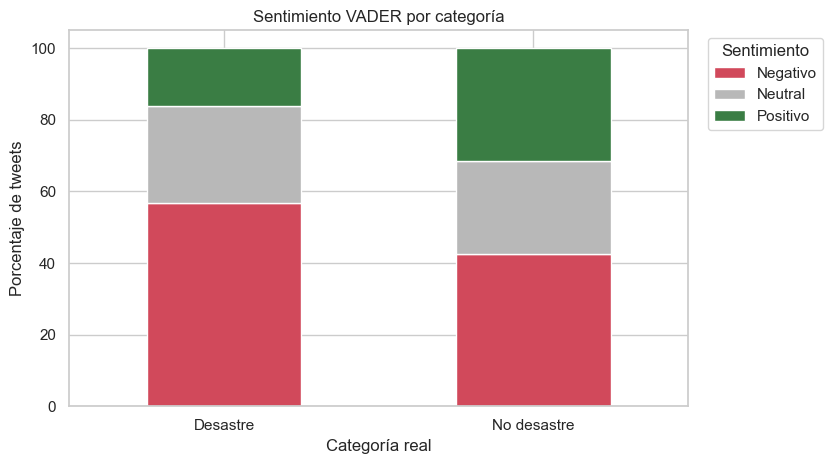

sentimiento,Negativo,Neutral,Positivo
target,,,
Desastre,56.9%,26.9%,16.2%
No desastre,42.5%,26.1%,31.4%


In [9]:
sent_order = ["Negativo", "Neutral", "Positivo"]
sent_by_class = pd.crosstab(
    df_sent["target"].map({0: "No desastre", 1: "Desastre"}),
    df_sent["sentimiento"], normalize="index"
).reindex(columns=sent_order) * 100

ax = sent_by_class.plot(kind="bar", stacked=True, figsize=(8.5, 4.8),
                        color=["#D1495B", "#B8B8B8", "#3A7D44"])
ax.set(xlabel="Categoría real", ylabel="Porcentaje de tweets",
       title="Sentimiento VADER por categoría")
ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(sent_by_class.style.format("{:.1f}%"))

## 9. Tweets extremos y comparación de negatividad

Los extremos se ordenan por el puntaje compuesto de VADER. Un compuesto cercano a −1 indica el tono más negativo y uno cercano a +1 el más positivo. Se conserva `target` para responder en qué categoría está cada tweet.

In [10]:
cols_top = ["id", "text", "target", "sent_negatividad", "sent_positividad", "sent_compuesto"]

top_negativos = df_sent.nsmallest(10, "sent_compuesto")[cols_top].copy()
top_positivos = df_sent.nlargest(10, "sent_compuesto")[cols_top].copy()
top_negativos["categoría"] = top_negativos["target"].map({0: "No desastre", 1: "Desastre real"})
top_positivos["categoría"] = top_positivos["target"].map({0: "No desastre", 1: "Desastre real"})

print("10 tweets más negativos")
display(top_negativos.drop(columns="target").style.format({
    "sent_negatividad": "{:.3f}", "sent_positividad": "{:.3f}", "sent_compuesto": "{:.4f}"
}))
print("Distribución por categoría:")
display(top_negativos["categoría"].value_counts().to_frame("tweets"))

print("\n10 tweets más positivos")
display(top_positivos.drop(columns="target").style.format({
    "sent_negatividad": "{:.3f}", "sent_positividad": "{:.3f}", "sent_compuesto": "{:.4f}"
}))
print("Distribución por categoría:")
display(top_positivos["categoría"].value_counts().to_frame("tweets"))

10 tweets más negativos


,id,text,sent_negatividad,sent_positividad,sent_compuesto,categoría
7472,10689,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,1.000,0.000,-0.9883,No desastre
6414,9172,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead This is ridiculous,0.542,0.000,-0.9686,Desastre real
6411,9166,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl,0.536,0.064,-0.9623,Desastre real
6393,9137,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp,0.583,0.000,-0.9595,Desastre real
6407,9159,17 killed in SÛªArabia mosque suicide bombing A suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX,0.579,0.000,-0.9552,Desastre real
2932,4213,at the lake *sees a dead fish* me: poor little guy i wonder what happened ashley: idk maybe it drowned wtf ????????,0.538,0.000,-0.9549,No desastre
472,682,illegal alien released by Obama/DHS 4 times Charged With Rape & Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO,0.536,0.000,-0.9538,Desastre real
1540,2225,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust,0.566,0.096,-0.9524,Desastre real
6818,9765,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,0.481,0.000,-0.9500,Desastre real
6930,9940,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.,0.481,0.060,-0.9493,Desastre real


Distribución por categoría:


,tweets
categoría,
Desastre real,8
No desastre,2



10 tweets más positivos


,id,text,sent_negatividad,sent_positividad,sent_compuesto,categoría
6992,10028,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1 I would Love Love Love!! To win,0.000,0.598,0.9730,No desastre
6534,9345,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!,0.049,0.539,0.9564,No desastre
6292,8989,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.,0.000,0.491,0.9471,Desastre real
3163,4541,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0.084,0.563,0.9423,No desastre
3382,4844,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0.084,0.563,0.9423,No desastre
6778,9710,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song,0.000,0.619,0.9394,No desastre
6295,8994,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite & Share,0.000,0.607,0.9376,No desastre
2457,3525,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :),0.000,0.575,0.9356,Desastre real
1001,1453,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0.061,0.566,0.9345,No desastre
6560,9386,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????,0.000,0.538,0.9344,No desastre


Distribución por categoría:


,tweets
categoría,
No desastre,8
Desastre real,2


### ¿Los tweets de desastre real son más negativos?

Se comparan dos variables complementarias:

- `sent_negatividad`: proporción del texto reconocida como negativa (mayor = más negativa);
- `sent_compuesto`: valencia global normalizada (menor = más negativa).

Además de medias y medianas, se aplica la prueba **U de Mann–Whitney**, apropiada porque los puntajes están acotados, tienen muchos empates y no se asume normalidad. La hipótesis alternativa unilateral es que la negatividad es mayor en desastres reales. Se reporta también una diferencia de medias: la significancia estadística por sí sola no indica el tamaño del efecto.

,tweets,negatividad_media,negatividad_mediana,compuesto_medio,compuesto_mediano,porcentaje_negativos
target,,,,,,
No desastre,4342,0.132,0.088,-0.061,0.000,42.5%
Desastre real,3271,0.174,0.157,-0.265,-0.318,56.9%


Diferencia de negatividad media (desastre − no desastre): +0.0413
Mann–Whitney U = 8,141,444; p unilateral = 2e-30
Correlación biserial por rangos (tamaño de efecto) = 0.146


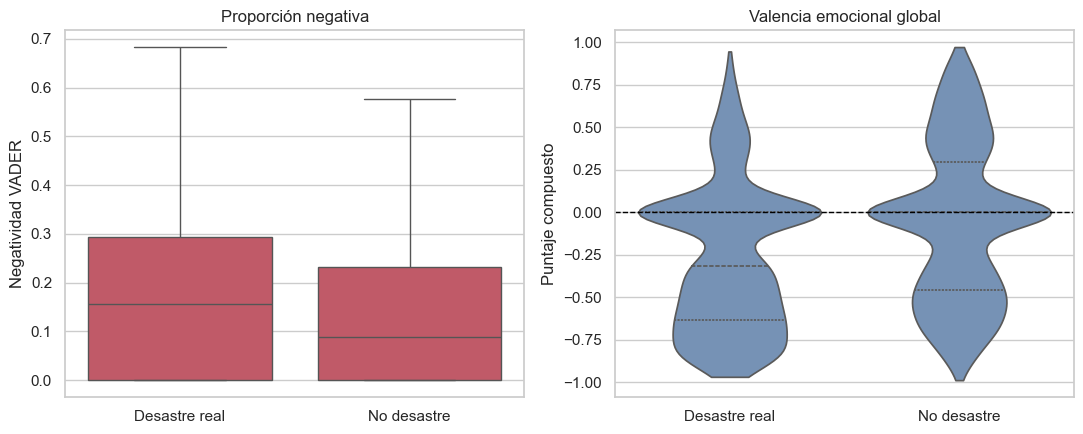

In [11]:
summary_sent = df_sent.groupby("target").agg(
    tweets=("id", "size"),
    negatividad_media=("sent_negatividad", "mean"),
    negatividad_mediana=("sent_negatividad", "median"),
    compuesto_medio=("sent_compuesto", "mean"),
    compuesto_mediano=("sent_compuesto", "median"),
    porcentaje_negativos=("sentimiento", lambda s: 100*(s == "Negativo").mean()),
).rename(index={0: "No desastre", 1: "Desastre real"})
display(summary_sent.style.format({
    "negatividad_media": "{:.3f}", "negatividad_mediana": "{:.3f}",
    "compuesto_medio": "{:.3f}", "compuesto_mediano": "{:.3f}",
    "porcentaje_negativos": "{:.1f}%"
}))

neg_real = df_sent.loc[df_sent.target == 1, "sent_negatividad"]
neg_no = df_sent.loc[df_sent.target == 0, "sent_negatividad"]
u_stat, p_value = mannwhitneyu(neg_real, neg_no, alternative="greater")
mean_diff = neg_real.mean() - neg_no.mean()
rank_biserial = 2*u_stat/(len(neg_real)*len(neg_no)) - 1

print(f"Diferencia de negatividad media (desastre − no desastre): {mean_diff:+.4f}")
print(f"Mann–Whitney U = {u_stat:,.0f}; p unilateral = {p_value:.3g}")
print(f"Correlación biserial por rangos (tamaño de efecto) = {rank_biserial:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_df = df_sent.assign(categoría=df_sent.target.map({0: "No desastre", 1: "Desastre real"}))
sns.boxplot(data=plot_df, x="categoría", y="sent_negatividad", ax=axes[0],
            color="#D1495B", showfliers=False)
axes[0].set(title="Proporción negativa", xlabel="", ylabel="Negatividad VADER")
sns.violinplot(data=plot_df, x="categoría", y="sent_compuesto", ax=axes[1],
               color="#6C91BF", inner="quartile", cut=0)
axes[1].axhline(0, color="black", lw=1, ls="--")
axes[1].set(title="Valencia emocional global", xlabel="", ylabel="Puntaje compuesto")
plt.tight_layout()
plt.show()

In [12]:
if p_value < 0.05 and mean_diff > 0:
    conclusion = "Sí: los tweets de desastre real presentan mayor negatividad según VADER."
elif p_value < 0.05:
    conclusion = "No: la diferencia significativa tiene la dirección contraria a la planteada."
else:
    conclusion = "No hay evidencia estadística suficiente de mayor negatividad en desastres reales."

print(conclusion)
print(
    "La magnitud debe interpretarse junto con el tamaño de efecto. "
    "VADER mide tono lingüístico y puede confundir usos figurados, sarcasmo, citas y titulares; "
    "no determina por sí mismo si ocurrió un desastre."
)

Sí: los tweets de desastre real presentan mayor negatividad según VADER.
La magnitud debe interpretarse junto con el tamaño de efecto. VADER mide tono lingüístico y puede confundir usos figurados, sarcasmo, citas y titulares; no determina por sí mismo si ocurrió un desastre.


## Conclusiones de los ejercicios 6–9

- La tabla de validación cruzada permite seleccionar el clasificador por evidencia y no por el resultado fortuito de una sola partición.
- TF–IDF con unigramas y bigramas aporta contexto local manteniendo interpretabilidad, aunque no resuelve ironía ni dependencias largas.
- El reporte y la matriz de confusión cuantifican el rendimiento final sobre tweets que no participaron en la selección.
- `clasificar_tweet()` encapsula el preprocesamiento y la predicción para nuevos mensajes.
- VADER se aplica al texto original porque puntuación, mayúsculas, negaciones y emoticonos aportan sentimiento.
- Las tablas de extremos responden cuáles son los diez tweets más positivos y negativos y muestran su categoría.
- La comparación descriptiva, la prueba U y el tamaño de efecto responden si los tweets de desastre real son más negativos, sin confundir significancia estadística con importancia práctica.

### Reproducibilidad y alcance

Se fijó `random_state=42`, se utilizaron particiones estratificadas y cada transformación aprendida está dentro de un `Pipeline`. Los resultados corresponden al `train.csv` de Kaggle disponible en este repositorio. VADER es un recurso léxico externo en inglés; por ello sus resultados deben entenderse como una aproximación y no como anotaciones humanas. La sección 10 incorpora la negatividad solo después de establecer esta línea base, usando exactamente la misma partición y el mismo clasificador para mantener una comparación justa.

## 10. Inclusión de la negatividad como nueva variable

En el análisis de sentimiento se observó que los tweets asociados con
desastres reales presentan, en promedio, una mayor negatividad que los
tweets clasificados como no desastre.

Por esta razón se evaluará si el puntaje de negatividad calculado mediante
VADER puede aportar información adicional al modelo de clasificación.

Para realizar una comparación justa se utilizarán los mismos conjuntos de
entrenamiento y prueba y el mismo clasificador seleccionado anteriormente.
La única diferencia será la incorporación de la variable de negatividad.

In [13]:
df_sent["negatividad"] = df_sent["sent_negatividad"]

df_sent[["text", "target", "negatividad"]].head()

,text,target,negatividad
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,0.000
1,Forest fire near La Ronge Sask. Canada,1,0.286
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,0.095
3,"13,000 people receive #wildfires evacuation orders in California",1,0.000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,0.000


In [14]:
df_sent.groupby("target")["negatividad"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
target,,,
0,0.132318,0.088,0.159648
1,0.173582,0.157,0.167870


In [15]:
# Usar train y test de la vez pasada 
columnas_modelo = [
    "texto_limpio",
    "negatividad"
]

X_train_neg = df_sent.loc[
    X_train.index,
    columnas_modelo
]

X_test_neg = df_sent.loc[
    X_test.index,
    columnas_modelo
]

print("Train:", X_train_neg.shape)
print("Test :", X_test_neg.shape)

Train: (6090, 2)
Test : (1523, 2)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [17]:
# Procesamiento combinado 
preprocesamiento_neg = ColumnTransformer([
    (
        "texto",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            norm="l2"
        ),
        "texto_limpio"
    ),
    (
        "negatividad",
        "passthrough",
        ["negatividad"]
    )
])

In [18]:
modelo_negatividad = Pipeline([
    ("variables", preprocesamiento_neg),
    ("modelo", clone(best_pipeline.named_steps["model"]))
])

In [19]:
modelo_negatividad.fit(
    X_train_neg,
    y_train
)

,steps,"[('variables', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('texto', ...), ('negatividad', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred_neg = modelo_negatividad.predict(
    X_test_neg
)

## Comparación de Modelos

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_original = best_pipeline.predict(X_test)

resultado_original = {
    "accuracy": accuracy_score(y_test, y_pred_original),
    "precision": precision_score(y_test, y_pred_original),
    "recall": recall_score(y_test, y_pred_original),
    "f1": f1_score(y_test, y_pred_original)
}

resultado_neg = {
    "accuracy": accuracy_score(y_test, y_pred_neg),
    "precision": precision_score(y_test, y_pred_neg),
    "recall": recall_score(y_test, y_pred_neg),
    "f1": f1_score(y_test, y_pred_neg)
}

In [22]:
comparacion = pd.DataFrame(
    [
        resultado_original,
        resultado_neg
    ],
    index=[
        "TF-IDF original",
        "TF-IDF + negatividad"
    ]
)

comparacion


,accuracy,precision,recall,f1
TF-IDF original,0.823375,0.835951,0.732416,0.780766
TF-IDF + negatividad,0.822062,0.833043,0.732416,0.779496


In [23]:
diferencia_f1 = (
    resultado_neg["f1"]
    - resultado_original["f1"]
)

print(
    "Cambio absoluto en F1:",
    round(diferencia_f1, 4)
)

Cambio absoluto en F1: -0.0013


In [24]:
cambio_porcentual = (
    diferencia_f1
    / resultado_original["f1"]
) * 100

print(
    "Cambio porcentual en F1:",
    round(cambio_porcentual, 2),
    "%"
)

Cambio porcentual en F1: -0.16 %


### Resultado de la inclusión de la negatividad

Al incorporar la variable `negatividad` al modelo de clasificación, el valor de F1 cambió en **-0.0013**, lo que representa una variación aproximada de **-0.16 %** respecto al modelo original.

Esto indica que la inclusión de la negatividad no mejoró el desempeño del clasificador. De hecho, se observó una disminución muy pequeña en F1.

Aunque en el análisis de sentimiento se encontró que los tweets asociados con desastres reales presentan una mayor negatividad promedio, esta información no aportó una mejora adicional al modelo cuando se combinó con la representación TF-IDF de unigramas y bigramas.

Una posible explicación es que el contenido textual ya captura palabras y expresiones relacionadas con situaciones negativas, por lo que la variable de negatividad puede contener información que ya está representada parcialmente por las características TF-IDF.

Por lo tanto, para este conjunto de datos no se justifica utilizar la negatividad como una variable adicional si el objetivo es mejorar el F1 del modelo.